# Double Gauss — Chief-Ray Distortion

A four-element double-Gauss photographic objective (the classic
Zeiss-Planar-derived form: two meniscus pairs symmetric about a central
aperture stop). Prescription reconstructed from the "four element double
gauss, intermediate optical design" reference lens distributed with the
open-source [rayopt-notebooks](https://github.com/quartiq/rayopt-notebooks)
project (`double_gauss.ipynb`); glass indices (SK4, F4) are d-line
(587.6 nm) values from the SCHOTT optical glass pocket catalog. It is a
textbook-scale example, not a claim of a specific commercial lens.

Unlike the [Cooke triplet](cooke_triplet.ipynb), this design's stop sits
at the geometric center of an (almost) mirror-symmetric element layout —
the classic reason double-Gauss lenses run distortion an order of
magnitude lower than an asymmetric triplet at a comparable field angle.
This notebook measures that directly with the chief-ray distortion metric,
and the two notebooks together are meant to be read side by side.

In [1]:
from importlib import resources
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.sequential import (
    FieldPoint, OpticalSystem, ParaxialModel, SequentialTracer,
    chief_ray_slope, solve_object_plane, trace_from_object,
)

CSV = resources.files("raytracer") / "data" / "double_gauss_prescription.csv"
system = OpticalSystem.from_prescription(CSV)
tracer = SequentialTracer(system)
conjugate = solve_object_plane(tracer)
efl = ParaxialModel(system).effective_focal_length()

print(f"{len(system)} surfaces, stop at index {system.stop_index}")
print(f"EFL = {efl:.3f} mm")
print(f"recovered object plane z = {conjugate.object_z:.1f} mm "
      f"(a large finite stand-in for the design's object at infinity)")
print(f"magnification = {conjugate.magnification:.6f}")

9 surfaces, stop at index 4
EFL = 98.949 mm
recovered object plane z = -10657.1 mm (a large finite stand-in for the design's object at infinity)
magnification = -0.009360


## Distortion vs. field angle

Same approach as the triplet notebook: field points are parametrized by
angle (the design's own object-angle convention, half field ~20.6°), each
angle is converted to an object height at the recovered finite conjugate,
and the chief ray (through the aperture-stop center) is solved with a
bracket centered on the paraxial angle estimate. Distortion is the chief
ray's departure from the ideal `magnification * y` line.

This reconstruction traces cleanly out to and beyond the design's stated
20.6° half field, unlike the triplet reconstruction which vignettes near
its own field edge.

 field (deg) |  image y (mm) |  distortion (um) | relative (ppm)
         0.0 |        0.0000 |            0.000 |            0.0
         5.0 |       -8.7275 |           -0.514 |           58.8
        10.0 |      -17.5896 |           -4.454 |          253.2
        15.0 |      -26.7294 |          -17.192 |          643.2
        20.0 |      -36.3080 |          -49.185 |         1354.7


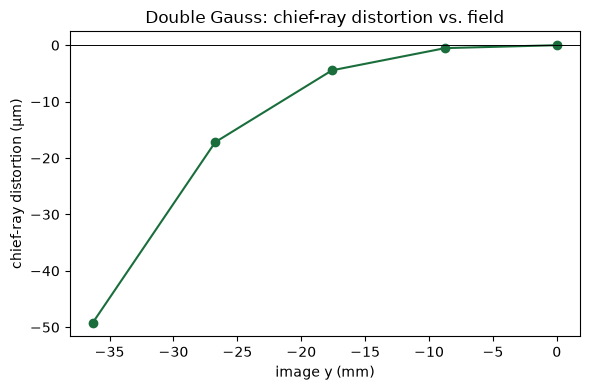

In [2]:
def chief_distortion(tracer, object_z, stop_index, magnification, angle_deg):
    if angle_deg == 0.0:
        return 0.0, 0.0, 0.0
    y = abs(object_z) * np.tan(np.deg2rad(angle_deg))
    z_stop = tracer.system.vertices[stop_index]
    estimate = -y / (z_stop - object_z)
    slope = chief_ray_slope(
        tracer, FieldPoint(y=y), stop_index=stop_index,
        bracket=(estimate - 0.02, estimate + 0.02), scan=101,
    )
    result = trace_from_object(tracer, (0.0, y), (0.0, slope))
    ideal_y = y * magnification
    distortion_um = (result.image_point[1] - ideal_y) * 1e3
    ppm = (result.image_point[1] / ideal_y - 1) * 1e6
    return y * magnification, distortion_um, ppm


FIELDS_DEG = [0.0, 5.0, 10.0, 15.0, 20.0]
rows = [chief_distortion(tracer, conjugate.object_z, system.stop_index,
                          conjugate.magnification, deg)
        for deg in FIELDS_DEG]

print(f"{'field (deg)':>12} | {'image y (mm)':>13} | {'distortion (um)':>16} | {'relative (ppm)':>14}")
for deg, (ideal_y, d_um, ppm) in zip(FIELDS_DEG, rows):
    print(f"{deg:12.1f} | {ideal_y:13.4f} | {d_um:16.3f} | {ppm:14.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([r[0] for r in rows], [r[1] for r in rows], "o-", color="#1a6e3c")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="image y (mm)", ylabel="chief-ray distortion (µm)",
       title="Double Gauss: chief-ray distortion vs. field")
fig.tight_layout()
plt.show()

## Triplet vs. double Gauss, at matching field angles

Comparing *relative* distortion (ppm) rather than absolute microns
controls for the two designs' different focal lengths (50 mm vs. ~99 mm)
and lets the stop-symmetry effect show through directly.

In [3]:
from raytracer.sequential import OpticalSystem as _OS, SequentialTracer as _ST, solve_object_plane as _sop

triplet_csv = resources.files("raytracer") / "data" / "cooke_triplet_prescription.csv"
triplet_system = _OS.from_prescription(triplet_csv)
triplet_tracer = _ST(triplet_system)
triplet_conjugate = _sop(triplet_tracer)

COMMON_FIELDS_DEG = [0.0, 2.0, 4.0, 6.0, 8.0]
print(f"{'field (deg)':>12} | {'triplet (ppm)':>14} | {'double gauss (ppm)':>19}")
for deg in COMMON_FIELDS_DEG:
    _, _, triplet_ppm = chief_distortion(triplet_tracer, triplet_conjugate.object_z,
                                          triplet_system.stop_index,
                                          triplet_conjugate.magnification, deg)
    _, _, dg_ppm = chief_distortion(tracer, conjugate.object_z, system.stop_index,
                                     conjugate.magnification, deg)
    print(f"{deg:12.1f} | {triplet_ppm:14.1f} | {dg_ppm:19.1f}")

 field (deg) |  triplet (ppm) |  double gauss (ppm)
         0.0 |            0.0 |                 0.0
         2.0 |           30.5 |                 9.2
         4.0 |          124.6 |                37.3
         6.0 |          289.8 |                85.7


         8.0 |          539.9 |               156.5
